Importing Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score, confusion_matrix

In [34]:
X_val_scaled   = pd.read_parquet('../data/processed/X_val_scaled.parquet')
X_test_scaled  = pd.read_parquet('../data/processed/X_test_scaled.parquet')

y_val          = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']
y_test         = pd.read_parquet('../data/processed/y_test.parquet')['isFraud']

Autoencoder training dont on only legitimate transactions to learn what normal looks like

In [35]:
# Load the raw (non-SMOTE) scaled train data
X_train_raw = pd.read_parquet('../data/processed/X_train_raw.parquet')
y_train_raw = pd.read_parquet('../data/processed/y_train_raw.parquet')['isFraud']

# Scale it using the saved scaler
scaler = joblib.load('../models/Standard_scaler.pkl')
X_train_raw_scaled = pd.DataFrame(
    scaler.transform(X_train_raw),
    columns=X_train_raw.columns
)

X_val_raw = pd.read_parquet('../data/processed/X_val.parquet')
X_val_raw_scaled = pd.DataFrame(
    scaler.transform(X_val_raw),
    columns=X_val_raw.columns
)

# Extract legitimate transactions only
legit_mask = (y_train_raw == 0)
X_train_legit = X_train_raw_scaled[legit_mask].values

y_val = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']
legit_val_mask = (y_val == 0)
X_val_legit = X_val_raw_scaled[legit_val_mask].values

print(f"Legitimate transactions for autoencoder: {len(X_train_legit):,}")

Legitimate transactions for autoencoder: 342,336


In [36]:
n_features = X_train_legit.shape[1]
n_features

216

Building Autoencoder Architecture

In [37]:
def build_autoencoder(n_features , encoding_dim = 32):
    input_layer = Input(shape=(n_features,), name='input')
    
    #Encoder
    x = Dense(128 , activation = 'relu' , name = 'enc1')(input_layer)
    x = BatchNormalization(name = 'bn_1')(x)
    x = Dropout(0.2 , name = 'drop_1')(x)

    x = Dense(64 , activation = 'relu' , name = 'enc2')(x)
    x = BatchNormalization(name = 'bn_2')(x)
    x = Dropout(0.2 , name = 'drop_2')(x)

    bottleneck = Dense(encoding_dim, activation='relu', name='bottleneck')(x)

    #Decoder
    x = Dense(64, activation='relu', name='dec_1')(bottleneck)
    x = BatchNormalization(name='bn_3')(x)
    
    x = Dense(128, activation='relu', name='dec_2')(x)
    x = BatchNormalization(name='bn_4')(x)

    output_layer = Dense(n_features, activation='linear', name='output')(x)

    model = Model(inputs = input_layer , outputs = output_layer)
    model.compile(optimizer = 'adam' , loss = 'mse')

    return model

autoencoder = build_autoencoder(n_features, encoding_dim=32)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 216)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 128)            │        27,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 216)            │        27,864 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,944 (304.47 KB)

 Trainable params: 77,176 (301.47 KB)

 Non-trainable params: 768 (3.00 KB)

Defining the Callbacks

In [38]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [41]:
print("Train legit feature stats:")
print(f"  Mean: {X_train_legit.mean():.4f}")
print(f"  Std:  {X_train_legit.std():.4f}")
print(f"  Max:  {X_train_legit.max():.4f}")
print(f"  Min:  {X_train_legit.min():.4f}")

print("\nVal legit feature stats:")
print(f"  Mean: {X_val_legit.mean():.4f}")
print(f"  Std:  {X_val_legit.std():.4f}")
print(f"  Max:  {X_val_legit.max():.4f}")
print(f"  Min:  {X_val_legit.min():.4f}")

# Check for extreme values
print(f"\nVal legit values > 100: {(X_val_legit > 100).sum()}")
print(f"Val legit values < -100: {(X_val_legit < -100).sum()}")

Train legit feature stats:
  Mean: -0.0007
  Std:  0.9712
  Max:  459.1826
  Min:  -242.3641

Val legit feature stats:
  Mean: 0.0762
  Std:  18.7813
  Max:  462.4091
  Min:  -37887.5271

Val legit values > 100: 60
Val legit values < -100: 2167


In [42]:
# Clip extreme values caused by -999 sentinels after scaling
# Values beyond ±10 std are almost certainly sentinel artifacts

clip_val = 10.0

X_train_legit_clipped = np.clip(X_train_legit, -clip_val, clip_val)
X_val_legit_clipped   = np.clip(X_val_legit, -clip_val, clip_val)

# Verify
print(f"Train after clipping: min={X_train_legit_clipped.min():.2f}, max={X_train_legit_clipped.max():.2f}, std={X_train_legit_clipped.std():.4f}")
print(f"Val after clipping:   min={X_val_legit_clipped.min():.2f}, max={X_val_legit_clipped.max():.2f}, std={X_val_legit_clipped.std():.4f}")

# Check how many values were clipped
clipped_count = (X_val_legit < -clip_val).sum() + (X_val_legit > clip_val).sum()
total = X_val_legit.size
print(f"\nVal values clipped: {clipped_count:,} / {total:,} ({clipped_count/total*100:.2f}%)")

Train after clipping: min=-10.00, max=10.00, std=0.8264
Val after clipping:   min=-10.00, max=10.00, std=0.7445

Val values clipped: 11,254 / 18,361,296 (0.06%)


Training the Autoencoder

In [43]:
X_val_array = X_val_scaled.values
history = autoencoder.fit(
    X_train_legit_clipped, X_train_legit_clipped,   # input = target (reconstruction)
    epochs=50,
    batch_size=256,
    validation_data=(X_val_legit_clipped, X_val_legit_clipped),    
    callbacks=[early_stopping, reduce_lr],
    shuffle=True,
    verbose=1
)

Epoch 1/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0898 - val_loss: 0.0912 - learning_rate: 2.5000e-04
Epoch 2/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0820 - val_loss: 0.0845 - learning_rate: 2.5000e-04
Epoch 3/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0754 - val_loss: 0.0781 - learning_rate: 2.5000e-04
Epoch 4/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0694 - val_loss: 0.0718 - learning_rate: 2.5000e-04
Epoch 5/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - loss: 0.0639 - val_loss: 0.0668 - learning_rate: 2.5000e-04
Epoch 6/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0594 - val_loss: 0.0611 - learning_rate: 2.5000e-04
Epoch 7/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 0.0557 - val_loss: 0.0576 - learning_rate: 2.5000e-04
Epoch 8/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0526 - val_loss: 0.0541 - learning_rate: 2.5000e-04
Epoch 9/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0

Reconstructing the error loss

In [44]:
X_val_raw = pd.read_parquet('../data/processed/X_val.parquet')
scaler = joblib.load('../models/Standard_scaler.pkl')
X_val_raw_scaled = pd.DataFrame(
    scaler.transform(X_val_raw),
    columns=X_val_raw.columns
)
X_val_clipped = np.clip(X_val_raw_scaled.values, -10.0, 10.0)

reconstructed_val = autoencoder.predict(X_val_clipped, verbose=0)
reconstruction_errors_val = np.mean(
    (X_val_clipped - reconstructed_val) ** 2,
    axis=1
)

fraud_errors = reconstruction_errors_val[y_val == 1]
legit_errors = reconstruction_errors_val[y_val == 0]

print(f"Fraud mean reconstruction error:      {fraud_errors.mean():.6f}")
print(f"Legitimate mean reconstruction error: {legit_errors.mean():.6f}")
print(f"Ratio: {fraud_errors.mean() / legit_errors.mean():.2f}x")

Fraud mean reconstruction error:      0.064696
Legitimate mean reconstruction error: 0.031807
Ratio: 2.03x


Reconstruction error plot

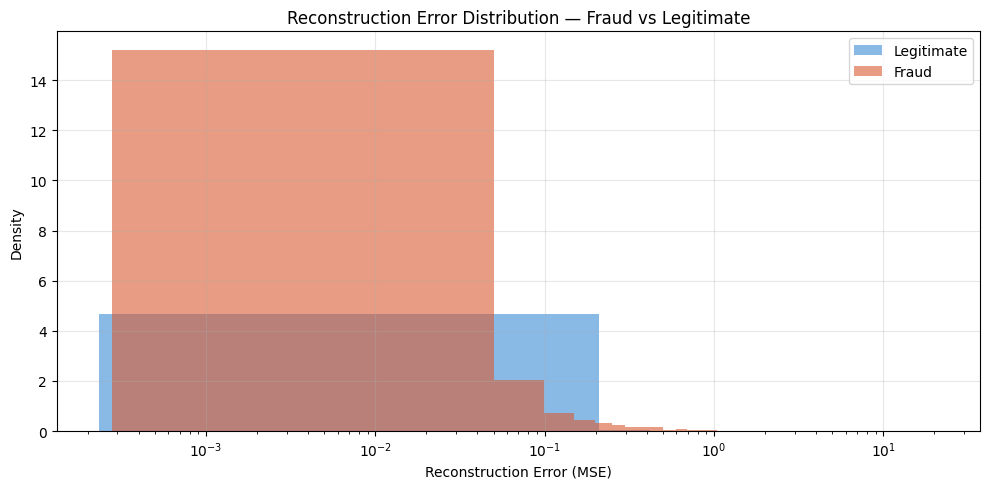

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(legit_errors, bins=100, alpha=0.6,
         color='#3B8BD4', label='Legitimate', density=True)
plt.hist(fraud_errors, bins=100, alpha=0.6,
         color='#D85A30', label='Fraud', density=True)

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution — Fraud vs Legitimate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

In [47]:
plt.savefig('../reports/autoencoder_reconstruction_errors.png', dpi=150)

<Figure size 640x480 with 0 Axes>

Finding the best threshold

In [48]:
pr_prec, pr_rec, thresholds = precision_recall_curve(y_val , reconstruction_errors_val)
f1_scores = 2 * (pr_prec * pr_rec) / (pr_prec + pr_rec + 1e-8)
best_idx        = f1_scores.argmax()
best_threshold_ae = thresholds[best_idx]
pr_auc_ae       = auc(pr_rec, pr_prec)

print(f"Autoencoder PR-AUC:  {pr_auc_ae:.4f}")
print(f"Best threshold:      {best_threshold_ae:.6f}")

Autoencoder PR-AUC:  0.0982
Best threshold:      0.035743


In [49]:
ae_preds = (reconstruction_errors_val >= best_threshold_ae).astype(int)
precision = precision_score(y_val, ae_preds, zero_division=0)
recall    = recall_score(y_val, ae_preds, zero_division=0)
f1        = f1_score(y_val, ae_preds, zero_division=0)
cm        = confusion_matrix(y_val, ae_preds)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

print(f"F1:        {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"FPR:       {fpr:.4f} ({fpr*100:.2f}% legitimate transactions blocked)")
print(f"\nConfusion Matrix:")
print(f"  TP: {tp:,}  FP: {fp:,}")
print(f"  FN: {fn:,}  TN: {tn:,}")

F1:        0.1948
Precision: 0.1425
Recall:    0.3074
FPR:       0.0778 (7.78% legitimate transactions blocked)

Confusion Matrix:
  TP: 1,099  FP: 6,612
  FN: 2,476  TN: 78,394


PR curve comparison: XGBoost vs Autoencoder

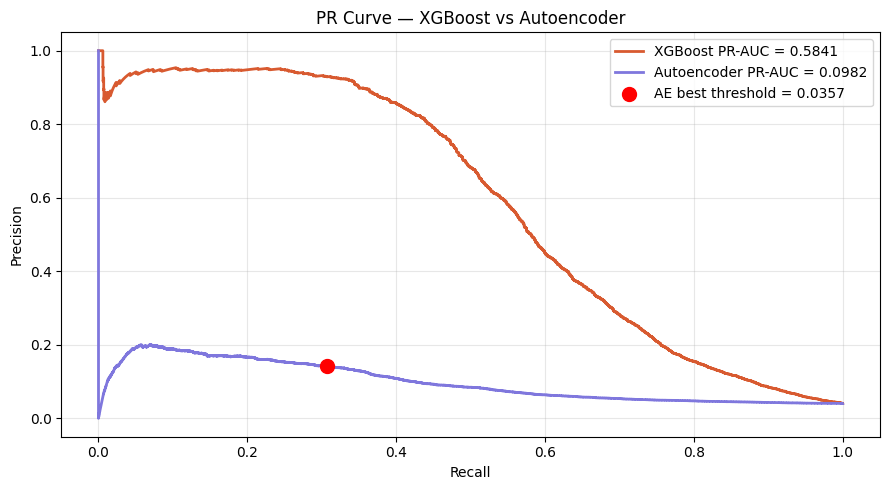

In [ ]:
import joblib

xgb_best = joblib.load('../models/xgboost_best.pkl')
X_val_unscaled = pd.read_parquet('../data/processed/X_val.parquet')

proba_xgb = xgb_best.predict_proba(X_val_unscaled)[:, 1]
pr_prec_xgb, pr_rec_xgb, _ = precision_recall_curve(y_val, proba_xgb)

plt.figure(figsize=(9, 5))
plt.plot(pr_rec_xgb, pr_prec_xgb, color='#D85A30', lw=2,
         label=f'XGBoost PR-AUC = {auc(pr_rec_xgb, pr_prec_xgb):.4f}')
plt.plot(pr_rec, pr_prec, color='#7F77DD', lw=2,
         label=f'Autoencoder PR-AUC = {pr_auc_ae:.4f}')
plt.scatter(pr_rec[best_idx], pr_prec[best_idx],
            color='red', s=100, zorder=5,
            label=f'AE best threshold = {best_threshold_ae:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve — XGBoost vs Autoencoder')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
plt.savefig('../reports/autoencoder_vs_xgb_pr_curve.png', dpi=150)

<Figure size 640x480 with 0 Axes>

In [52]:
autoencoder.save('../models/autoencoder.keras')

In [54]:
joblib.dump({'ae_threshold': float(best_threshold_ae), 'ae_clip_val': 10.0}, '../models/ae_threshold.pkl')

['../models/ae_threshold.pkl']